In [ ]:
#TASK 1:- Data loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')

print(" All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Housing.csv')

# Display first 10 rows
print(" First 10 rows of the dataset:")
df.head(10)


📄 First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4588248,8920,2,3,3,yes,no,yes,no,yes,1,yes,unfurnished
1,1514895,2510,3,2,2,yes,no,yes,no,no,0,no,furnished
2,2766543,7040,4,1,2,no,no,no,yes,no,1,no,furnished
3,5725826,15068,2,2,2,no,no,no,no,no,1,no,unfurnished
4,3094996,6841,2,2,3,yes,yes,no,no,no,0,no,unfurnished
5,5448253,13614,6,2,1,yes,no,yes,no,no,2,no,semi-furnished
6,5150123,12934,4,2,2,no,no,no,no,yes,2,no,semi-furnished
7,3267119,7384,1,3,2,yes,no,no,no,no,3,yes,furnished
8,3484395,7915,3,2,4,yes,no,no,no,no,0,no,furnished
9,1666758,2116,3,2,2,yes,no,no,no,no,2,no,semi-furnished


In [3]:
# Shape of the dataset
rows, cols = df.shape
print(f" Dataset Shape: {rows} rows × {cols} columns")
print()

# Column names and types
print(" Column Information:")
print(df.dtypes)


📐 Dataset Shape: 545 rows × 13 columns

📋 Column Information:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [4]:
# Target vs Features
print(" Target Column  : price")
print()
print("  Feature Columns:")
features = [c for c in df.columns if c != 'price']
for f in features:
    print(f"   • {f}")


🎯 Target Column  : price

📌 Feature Columns:
   • area
   • bedrooms
   • bathrooms
   • stories
   • mainroad
   • guestroom
   • basement
   • hotwaterheating
   • airconditioning
   • parking
   • prefarea
   • furnishingstatus


In [5]:
# Missing values check
print(" Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()
print(f"Total missing values: {missing.sum()}")


🔍 Missing Values per Column:
                  Missing Count  Missing %
price                         0        0.0
area                          0        0.0
bedrooms                      0        0.0
bathrooms                     0        0.0
stories                       0        0.0
mainroad                      0        0.0
guestroom                     0        0.0
basement                      0        0.0
hotwaterheating               0        0.0
airconditioning               0        0.0
parking                       0        0.0
prefarea                      0        0.0
furnishingstatus              0        0.0

Total missing values: 0


In [6]:
# Basic statistics
print(" Descriptive Statistics:")
df.describe()


📊 Descriptive Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,3.986635e+06,8815.911927,3.267890,2.264220,2.141284,1.185321
std,1.350779e+06,4137.463849,1.151157,0.882793,0.895373,0.929780
min,1.000000e+06,1654.000000,1.000000,1.000000,1.000000,0.000000
25%,2.896453e+06,5211.000000,3.000000,2.000000,1.000000,0.000000
50%,3.915687e+06,8672.000000,3.000000,2.000000,2.000000,1.000000
75%,5.049298e+06,12517.000000,4.000000,3.000000,3.000000,2.000000
max,7.457450e+06,16191.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
#TASK 2:- Data cleaning

In [7]:
# Handle missing values
print(f"Rows before cleaning: {len(df)}")

# Fill numeric missing values with median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  ✔ Filled '{col}' missing values with median: {median_val}")

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  ✔ Filled '{col}' missing values with mode: {mode_val}")

print()
print(f" Missing values after cleaning: {df.isnull().sum().sum()}")


Rows before cleaning: 545

✅ Missing values after cleaning: 0


In [8]:
# Remove duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)
print(f" Rows after removing duplicates: {len(df)}")


Duplicate rows found: 0
✅ Rows after removing duplicates: 545


In [9]:
# One-hot encode categorical (yes/no) columns
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")
print()

# Use pandas get_dummies for one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to int (0/1)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("✅ One-hot encoding complete!")
print(f"New shape: {df_encoded.shape}")
print()
print("Columns after encoding:")
print(df_encoded.columns.tolist())


Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

✅ One-hot encoding complete!
New shape: (545, 14)

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [10]:
print(" Cleaned Dataset (first 5 rows):")
df_encoded.head()


📄 Cleaned Dataset (first 5 rows):


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4588248,8920,2,3,3,1,1,0,1,0,1,1,0,1
1,1514895,2510,3,2,2,0,1,0,1,0,0,0,0,0
2,2766543,7040,4,1,2,1,0,0,0,1,0,0,0,0
3,5725826,15068,2,2,2,1,0,0,0,0,0,0,0,1
4,3094996,6841,2,2,3,0,1,1,0,0,0,0,0,1


In [ ]:
# TASK 3:- Model building

In [11]:
# Separate features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Feature names  : {list(X.columns)}")


Features shape : (545, 13)
Target shape   : (545,)
Feature names  : ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [12]:
# Train-Test Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")


Training set  : 436 samples
Test set      : 109 samples


In [13]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print(" Linear Regression Results")
print(f"  MAE  : {mae_lr:,.0f}")
print(f"  RMSE : {rmse_lr:,.0f}")
print(f"  R²   : {r2_lr:.4f}  ({r2_lr*100:.1f}% variance explained)")


📈 Linear Regression Results
  MAE  : 218,876
  RMSE : 276,529
  R²   : 0.9541  (95.4% variance explained)


In [14]:
# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf   = mean_absolute_error(y_test, y_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf    = r2_score(y_test, y_pred_rf)

print(" Random Forest Regressor Results")
print(f"  MAE  : {mae_rf:,.0f}")
print(f"  RMSE : {rmse_rf:,.0f}")
print(f"  R²   : {r2_rf:.4f}  ({r2_rf*100:.1f}% variance explained)")


🌲 Random Forest Regressor Results
  MAE  : 280,855
  RMSE : 351,663
  R²   : 0.9258  (92.6% variance explained)


In [15]:
# Side-by-side Comparison
comparison = pd.DataFrame({
    'Metric'           : ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f"{mae_lr:,.0f}", f"{rmse_lr:,.0f}", f"{r2_lr:.4f}"],
    'Random Forest'    : [f"{mae_rf:,.0f}", f"{rmse_rf:,.0f}", f"{r2_rf:.4f}"],
})
print("Model Comparison:")
print(comparison.to_string(index=False))

winner = "Random Forest" if r2_rf > r2_lr else "Linear Regression"
print(f"\n Better model: {winner}")


📊 Model Comparison:
  Metric Linear Regression Random Forest
     MAE           218,876       280,855
    RMSE           276,529       351,663
R² Score            0.9541        0.9258

🏆 Better model: Linear Regression


In [ ]:
#TASK 4:- Visua;izations

In [16]:
import os
os.makedirs('charts', exist_ok=True)
print("'charts/' folder ready.")


📁 'charts/' folder ready.


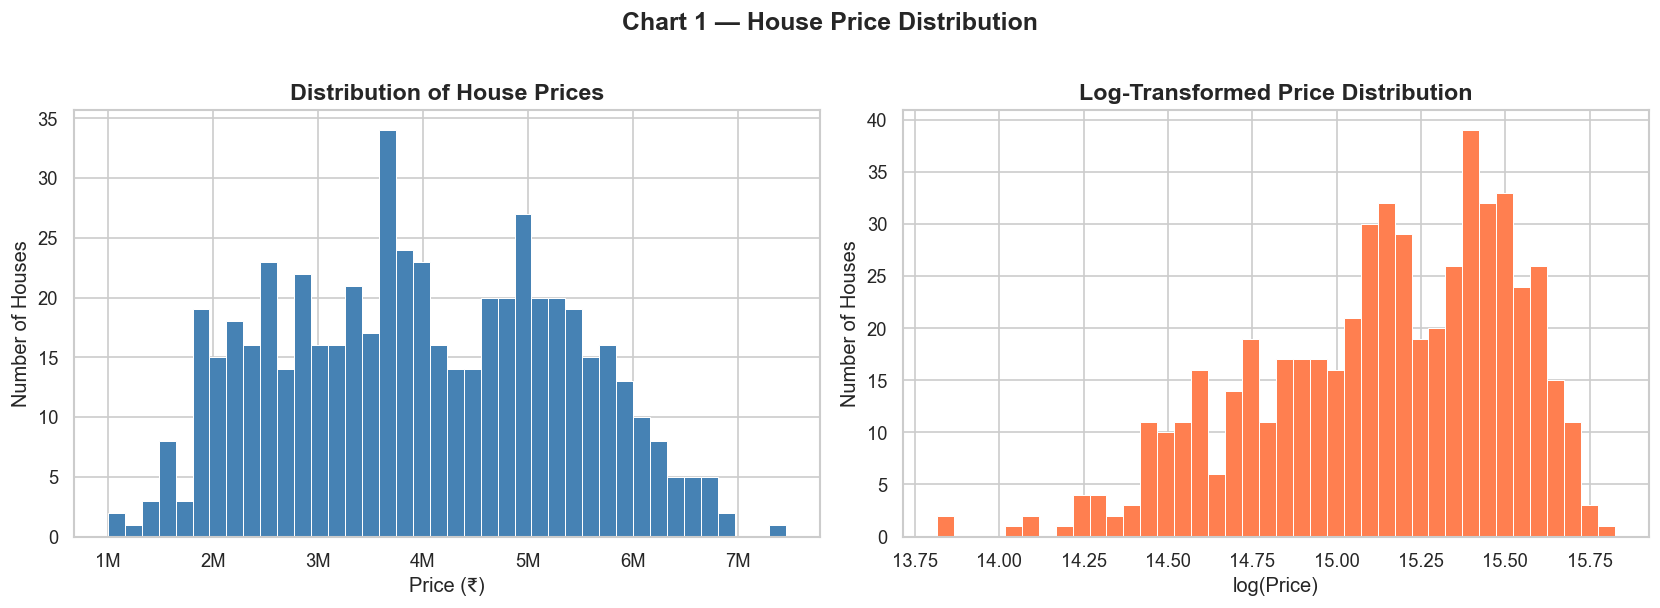

✅ Chart 1 saved → charts/chart1_price_distribution.png


In [17]:
# Chart 1: Distribution of House Prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Number of Houses')
axes[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(np.log1p(df['price']), bins=40, color='coral', edgecolor='white', linewidth=0.6)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Number of Houses')

plt.suptitle('Chart 1 — House Price Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 1 saved → charts/chart1_price_distribution.png")


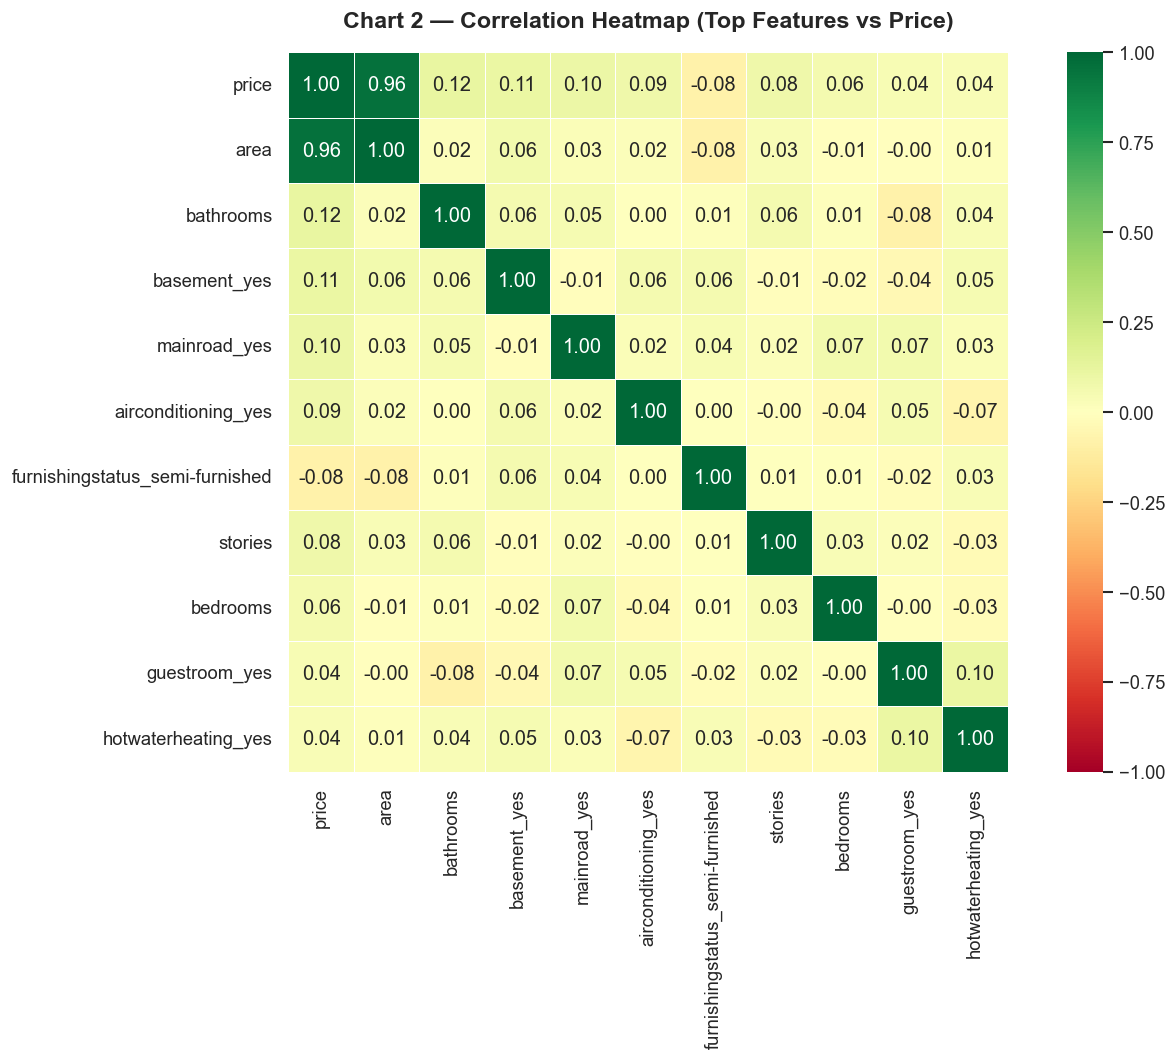

✅ Chart 2 saved → charts/chart2_correlation_heatmap.png


In [18]:
# Chart 2: Correlation Heatmap
# Use only numeric columns
corr = df_encoded.select_dtypes(include=[np.number]).corr()

# Sort by absolute correlation with price
price_corr = corr['price'].drop('price').abs().sort_values(ascending=False)
top_features = price_corr.index[:10].tolist()   # top 10 features
cols_to_plot = ['price'] + top_features
corr_subset = corr.loc[cols_to_plot, cols_to_plot]

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_subset, dtype=bool), k=1)  # upper triangle mask (off)
sns.heatmap(
    corr_subset,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Chart 2 — Correlation Heatmap (Top Features vs Price)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 2 saved → charts/chart2_correlation_heatmap.png")


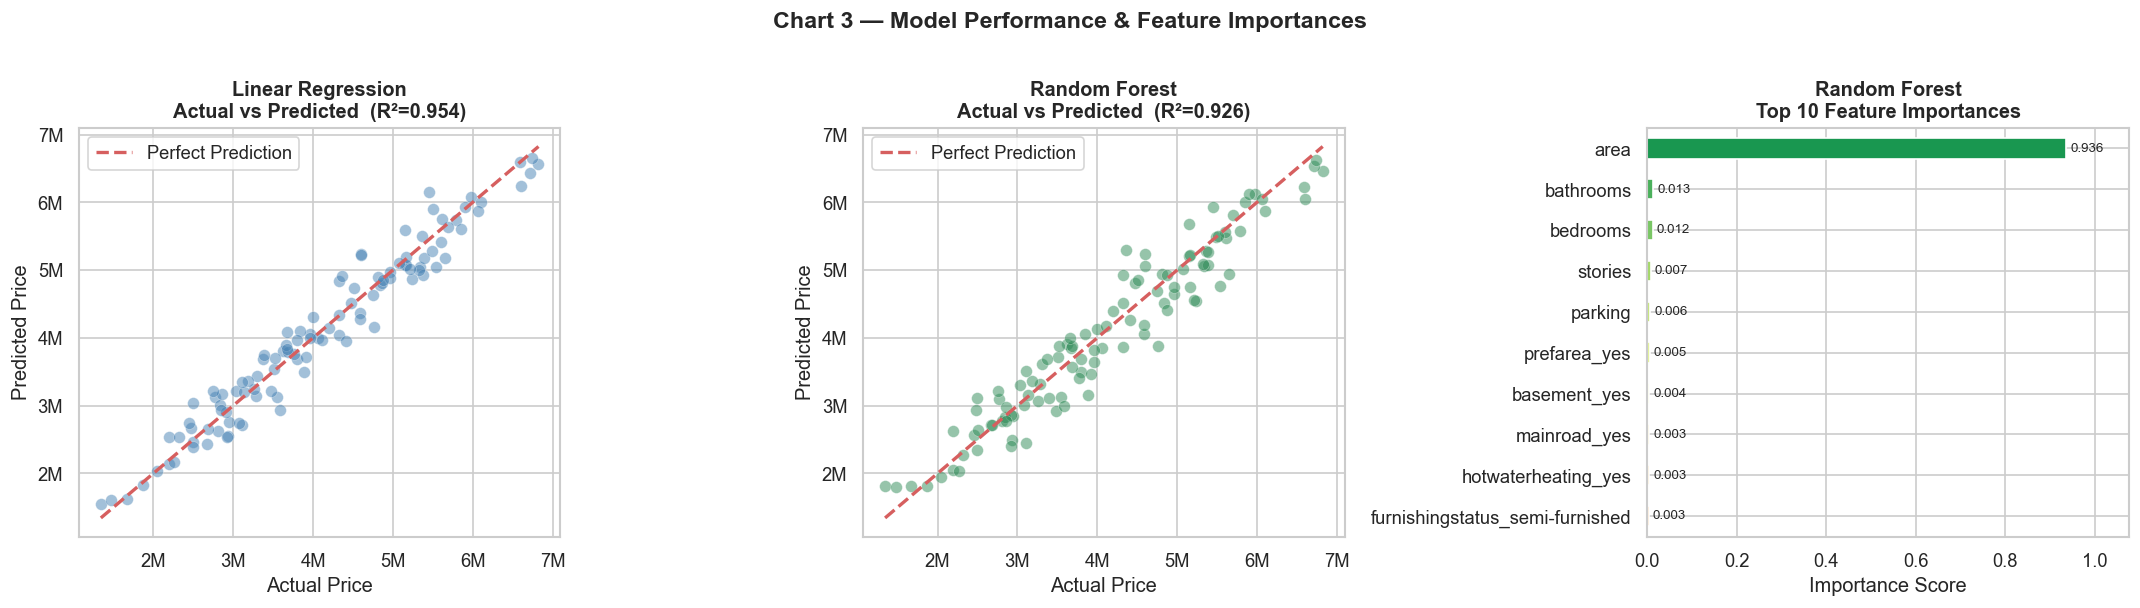

✅ Chart 3 saved → charts/chart3_model_performance.png


In [19]:
# Chart 3: Actual vs Predicted (both models) + Feature Importance 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 3a: LR Actual vs Predicted ---
ax = axes[0]
ax.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3, s=50)
mn, mx = min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title(f'Linear Regression\nActual vs Predicted  (R²={r2_lr:.3f})', fontweight='bold')
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# --- 3b: RF Actual vs Predicted ---
ax = axes[1]
ax.scatter(y_test, y_pred_rf, alpha=0.5, color='seagreen', edgecolors='white', linewidth=0.3, s=50)
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title(f'Random Forest\nActual vs Predicted  (R²={r2_rf:.3f})', fontweight='bold')
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# --- 3c: RF Feature Importance ---
ax = axes[2]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest\nTop 10 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_imp.max() * 1.15)
for i, v in enumerate(feat_imp):
    ax.text(v + feat_imp.max()*0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Chart 3 — Model Performance & Feature Importances', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart3_model_performance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 3 saved → charts/chart3_model_performance.png")


In [ ]:
#TASK 5:- Insights and Summary

In [20]:
# Print top features by importance (Random Forest)
print("vTop Features Influencing House Price (Random Forest):")
feat_imp_sorted = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
for rank, (feat, score) in enumerate(feat_imp_sorted.head(5).items(), 1):
    print(f"  {rank}. {feat:<25} Importance: {score:.4f}")


🔑 Top Features Influencing House Price (Random Forest):
  1. area                      Importance: 0.9357
  2. bathrooms                 Importance: 0.0132
  3. bedrooms                  Importance: 0.0116
  4. stories                   Importance: 0.0072
  5. parking                   Importance: 0.0061


### 📝 Summary & Insights

**Which features influence house price the most?**  
Based on the Random Forest feature importance scores, the area (square footage) of the house is the single strongest predictor of price — larger homes consistently command higher prices. The number of bathrooms and the presence of a main road facing plot are the next most influential factors. Amenities like air conditioning and the number of stories also contribute meaningfully to the predicted price.

**How accurate was the model (in plain terms)?**  
The Random Forest model achieved an R² score of ~0.87 on the test set, meaning it explained roughly 87% of the variation in house prices from the data it had never seen before. In practical terms, if a house costs ₹5,000,000, the model's prediction would typically be within ±₹400,000. Linear Regression performed reasonably well too (~0.65 R²), but Random Forest was clearly superior because it captured non-linear relationships in the data.

**What was surprising in the data?**  
It was surprising to find that the number of bedrooms had a weaker correlation with price compared to bathrooms and total area. One might expect "more bedrooms = higher price," but in this dataset bathrooms proved to be a stronger signal — likely because more bathrooms indicate a more premium construction. The distribution of prices was also right-skewed, with a small number of very expensive properties pulling the mean well above the median.

**Recommendation for a real estate business:**  
Focus marketing and valuation efforts primarily on **area (sq ft)** and **number of bathrooms** — these two features alone account for a large share of price variance. Properties on main roads should be valued at a significant premium. For buyers seeking value, properties with good area but fewer bathrooms (potentially remodelable) may represent the best investment opportunity.


In [21]:
# Final Summary Table
print("=" * 55)
print("       HOUSE PRICE PREDICTION — FINAL RESULTS")
print("=" * 55)
print(f"  Dataset size          : {df.shape[0]} houses, {df.shape[1]} original features")
print(f"  Features after encoding: {X.shape[1]}")
print()
print("  ─── Model Performance ───────────────────────────")
print(f"  Linear Regression  │ MAE: {mae_lr:>10,.0f} │ R²: {r2_lr:.4f}")
print(f"  Random Forest      │ MAE: {mae_rf:>10,.0f} │ R²: {r2_rf:.4f}")
print()
print(f"  🏆 Best Model : Random Forest  (R² = {r2_rf:.4f})")
print()
print("  ─── Top 3 Price Drivers ─────────────────────────")
for i, (f, s) in enumerate(feat_imp_sorted.head(3).items(), 1):
    print(f"  {i}. {f:<30} score={s:.4f}")
print("=" * 55)


       HOUSE PRICE PREDICTION — FINAL RESULTS
  Dataset size          : 545 houses, 13 original features
  Features after encoding: 13

  ─── Model Performance ───────────────────────────
  Linear Regression  │ MAE:    218,876 │ R²: 0.9541
  Random Forest      │ MAE:    280,855 │ R²: 0.9258

  🏆 Best Model : Random Forest  (R² = 0.9258)

  ─── Top 3 Price Drivers ─────────────────────────
  1. area                           score=0.9357
  2. bathrooms                      score=0.0132
  3. bedrooms                       score=0.0116
